# Model Selection
In this notebook, we will: 
- Establish our evaluation metrics 
- Initialise `MLFlow`
- Define Training Sklearn Pipeline Object
- Establish a baseline model 
- Train different models and find the best one by logging in `MLFlow`

## 1. Establishing Evaluation Metrics

The target values are heavily imbalanced i.e `Charged Off` loan are significantly rarer than `Fully Paid` ones. Due to this heavy class imbalance, using accuracy is misleading and insufficient. Considering `Charged Off` loans as the positive class (1) and the `Fully Paid` loans as the negative class (0), we can define TN, FN, TP, FP, Precision and Recall 

- **True Negative (TN)** - A `Charged Off` loan is correctly classified as `Charged Off`

- **False Negative (FN)** - A `Charged Off` loan  is misclassified as `Fully Paid`. In the context of lending institutions, loans that would have been charged off were materialised/accepted

- **True Positive (TP)** - A `Fully Paid` loan is correctly classified as `Fully Paid`

- **False Positive (FP)** - A `Fully Paid` loan is misclassified as `Charged Off`. Loans that would be have been paid off were rejected

- **Precision** = $\frac{TP}{TP + FP}$

- **Recall** = $\frac{TP}{TP + FN}$

In this scenario, a FN is more costly than a FP as there is a direct loss of capital incurred by the lender/lending institution. Thus, we would minimise the false negative rate and maximise the `recall`. Since lending institutions still should accept a certain degree of loans to gain profit, the false positive rate should not be extremely high. Hence, a smaller focus is also required to increase precision. To address this need for balance, we can use the `F-beta measure` with a `beta = 2` and the `precision-recall` curve.


$$
F_{\beta}=\left(1+\beta^{2}\right)\frac{\text{Precision}\cdot \text{Recall}}{\beta^{2}\cdot \text{Precision}+\text{Recall}}
$$

Where:
- $\beta > 1$ emphasizes **recall**
- $\beta < 1$ emphasizes **precision**
- $\beta = 1$ gives the **F1-score**

We finalise `recall` and `F2 score` as our evaluation metrics and `precision-recall curve` for visualisations.


## 2. Initialise MLFlow

In [ ]:
import mlflow 

%env MLFLOW_TRACKING_URI = sqlite:///../mlflow.db # use of relative paths 

# may be a problem 

env: MLFLOW_TRACKING_URI=sqlite:///../mlflow.db


## 3. Training Sklearn Pipeline Object

Create the training pipeline function and also initialise the `MLFlow` database to store and log experiment runs

In [1]:
import pandas as pd 

filepath_xtrain = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/xtrain.csv" # filepath to train split 

filepath_ytrain = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/ytrain.csv" # filepath to train split 

X_train = pd.read_csv(filepath_xtrain)

y_train = pd.read_csv(filepath_ytrain)

In [45]:
from sklearn.model_selection import StratifiedKFold

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

strat_splits = []

for train_index, val_index in splitter.split(X_train, y_train): 

    strat_train_set_n = X_train.iloc[train_index]

    strat_y_train_set_n = y_train.iloc[train_index]['loan_status']

    strat_val_set_n = X_train.iloc[val_index]

    strat_y_val_set_n = y_train.iloc[val_index]['loan_status']

    strat_splits.append([strat_train_set_n, strat_val_set_n, strat_y_train_set_n, strat_y_val_set_n])

In [ ]:
import numpy as np
import mlflow
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer, 
    precision_score, 
    recall_score, 
    fbeta_score, 
    precision_recall_curve, 
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
FEATURES = ['int_rate','fico_range_high','inq_last_6mths','open_il_12m','acc_open_past_24mths','mort_acc','num_tl_op_past_12m','percent_bc_gt_75',
    'term','sub_grade']

NUMERICAL_FEATURES = ['int_rate','fico_range_high','inq_last_6mths','open_il_12m','acc_open_past_24mths','mort_acc','num_tl_op_past_12m','percent_bc_gt_75']

CATEGORICAL_FEATURES = ['term', 'sub_grade']


In [ ]:
impute = ColumnTransformer(
    [
        ("numerical_imputation", SimpleImputer(strategy='median'), NUMERICAL_FEATURES), 
        ("categorical_impuutation", SimpleImputer(strategy='most_frequent'), CATEGORICAL_FEATURES)
    ], 
    remainder='passthrough', 
    verbose=True, 
    verbose_feature_names_out=False
)

encode = ColumnTransformer(
    [
        ("one_hot_encoding", OneHotEncoder(drop='first', sparse_output=False, dtype=np.int64), ['term']), 
        ("ordinal_encoding", OrdinalEncoder(dtype=np.int64), ['sub_grade']), 
    ],
    remainder='passthrough', 
    verbose=True, 
    verbose_feature_names_out=False
)

scale = make_column_transformer(
    (RobustScaler(), NUMERICAL_FEATURES),
    remainder='passthrough', 
    verbose=True, 
    verbose_feature_names_out=False
)

In [78]:
def train(model, experiment_name): 

    f, axes = plt.subplots(1, 2, figsize=(10, 5))

    # define training pipeline 
    training_pipeline = Pipeline([
        ("n",impute),
        ("c",encode),
        ("s", scale),
        ("m", model[1])
    ])

    y_real = []
    y_proba = []

    y_pred_val = []

    avg_train_recall = []
    avg_val_recall = []
    avg_train_precision = []
    avg_val_precision = []
    avg_train_fbeta = []
    avg_val_fbeta = []

    with mlflow.start_run(run_name=f'{model[0]}'):

        mlflow.set_tags({
            "model_type": model[0],
            "experiment_phase": experiment_name,
        }) # set tags 

        for index in range(len(strat_splits)): 

            with mlflow.start_run(nested=True):

                Xtrain, Xval, ytrain, yval = strat_splits[index]

                Xtrain, Xval, ytrain, yval = Xtrain[FEATURES], Xval[FEATURES], ytrain.map({'Charged Off':1, 'Fully Paid':0}), yval.map({'Charged Off':1, 'Fully Paid':0})

                mlflow.log_param("feature_names", FEATURES)
                mlflow.log_param("split_number", index)

                # log feature names 
                mlflow.log_param("features", FEATURES)
                # log split number 
                mlflow.log_param("split_number", index)
                # log model params 
                mlflow.log_params(model[2])

                training_pipeline.fit(Xtrain, ytrain)

                # get the metrics (recall, precision, F2)

                y_train_pred = training_pipeline.predict(Xtrain)
                y_val_pred = training_pipeline.predict(Xval)

                y_pred_val.append(y_val_pred)

                # recall, precision # may encounter issues if they are not numerical so if you do convert them to nbinary 0s and 1s 

                recall_train = recall_score(ytrain, y_train_pred)
                avg_train_recall.append(recall_train)

                recall_val = recall_score(yval, y_val_pred)
                avg_val_recall.append(recall_val)

                precision_train = precision_score(ytrain, y_train_pred)
                avg_train_precision.append(precision_train)

                precision_val = precision_score(yval, y_val_pred)
                avg_val_precision.append(precision_val)

                fbeta_train = fbeta_score(ytrain, y_train_pred, beta=2)
                avg_train_fbeta.append(fbeta_train)

                fbeta_val = fbeta_score(yval, y_val_pred, beta=2)
                avg_val_fbeta.append(fbeta_val)

                # log metrics in mlflow

                child_metrics = {
                    "train_recall": recall_train,
                    "validation_recall": recall_val, 
                    "train_precision": precision_train,
                    "validation_precision": precision_val,
                    "train_fbeta": fbeta_train,
                    "validation_fbeta": fbeta_val
                }

                mlflow.log_metrics(metrics=child_metrics)

                ## this is a child run (log precision, recall and f-beta)

                # make and plot precision-recall 

                pred_proba = training_pipeline.predict_proba(Xval)
                precision, recall, _ = precision_recall_curve(yval, pred_proba[:,1])
                lab = 'Fold %d AUC=%.4f' % (index+1, auc(recall, precision))
                axes[0].step(recall, precision, label=lab)
                y_real.append(yval)
                y_proba.append(pred_proba[:,1]) 

        # plot final precision-recall
        y_real = np.concatenate(y_real)
        y_proba = np.concatenate(y_proba)
        precision, recall, _ = precision_recall_curve(y_real, y_proba)
        lab = 'Overall AUC=%.4f' % (auc(recall, precision))
        axes[0].step(recall, precision, label=lab, lw=2, color='black')
        axes[0].set_xlabel('Recall')
        axes[0].set_ylabel('Precision')
        axes[0].legend(loc='lower left', fontsize='small')

        # # plot confusion matrix 
        y_pred_val = np.concatenate(y_pred_val)
        matrix = confusion_matrix(y_real, y_pred_val)
        disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
        disp.plot(ax=axes[1])
        axes[1].set_title('Confusion Matrix')

        # log average recall, precision and f-beta 

        parent_metrics = {
                        "train_recall": np.mean(avg_train_recall),
                        "validation_recall": np.mean(avg_val_recall), 
                        "train_precision": np.mean(avg_train_precision),
                        "validation_precision": np.mean(avg_val_precision),
                        "train_fbeta": np.mean(avg_train_fbeta),
                        "validation_fbeta": np.mean(avg_val_fbeta)
                    }

        mlflow.log_metrics(metrics=parent_metrics)

        # log the confusion matrix and PR curve 

        f.tight_layout()

        mlflow.log_figure(figure=f, artifact_file="cm_pr.png")

        f.savefig('result.png')

In [ ]:
# def train(model): 

#     f, axes = plt.subplots(1, 2, figsize=(10, 5))

#     # define training pipeline 
#     training_pipeline = Pipeline([
#         ("n",impute),
#         ("c",encode),
#         ("s", scale),
#         ("m", model[1])
#     ])

#     y_real = []
#     y_proba = []

#     y_pred_val = []

#     avg_train_recall = []
#     avg_val_recall = []
#     avg_train_precision = []
#     avg_val_precision = []
#     avg_train_fbeta = []
#     avg_val_fbeta = []


#     for index in range(len(strat_splits)): 

#         Xtrain, Xval, ytrain, yval = strat_splits[index]

#         Xtrain, Xval, ytrain, yval = Xtrain[FEATURES], Xval[FEATURES], ytrain.map({'Charged Off':1, 'Fully Paid':0}), yval.map({'Charged Off':1, 'Fully Paid':0})

#         training_pipeline.fit(Xtrain, ytrain)

#         # get the metrics (recall, precision, F2)

#         y_train_pred = training_pipeline.predict(Xtrain)
#         y_val_pred = training_pipeline.predict(Xval)

#         y_pred_val.append(y_val_pred)

#         # recall, precision # may encounter issues if they are not numerical so if you do convert them to nbinary 0s and 1s 

#         recall_train = recall_score(ytrain, y_train_pred)
#         avg_train_recall.append(recall_train)

#         recall_val = recall_score(yval, y_val_pred)
#         avg_val_recall.append(recall_val)

#         precision_train = precision_score(ytrain, y_train_pred)
#         avg_train_precision.append(precision_train)

#         precision_val = precision_score(yval, y_val_pred)
#         avg_val_precision.append(precision_val)

#         fbeta_train = fbeta_score(ytrain, y_train_pred, beta=2)
#         avg_train_fbeta.append(fbeta_train)

#         fbeta_val = fbeta_score(yval, y_val_pred, beta=2)
#         avg_val_fbeta.append(fbeta_val)

#         ## this is a child run (log precision, recall and f-beta)

#         # make and plot precision-recall 

#         pred_proba = training_pipeline.predict_proba(Xval)
#         precision, recall, _ = precision_recall_curve(yval, pred_proba[:,1])
#         lab = 'Fold %d AUC=%.4f' % (index+1, auc(recall, precision))
#         axes[0].step(recall, precision, label=lab)
#         y_real.append(yval)
#         y_proba.append(pred_proba[:,1]) 

#     # plot final precision-recall
#     y_real = np.concatenate(y_real)
#     y_proba = np.concatenate(y_proba)
#     precision, recall, _ = precision_recall_curve(y_real, y_proba)
#     lab = 'Overall AUC=%.4f' % (auc(recall, precision))
#     axes[0].step(recall, precision, label=lab, lw=2, color='black')
#     axes[0].set_xlabel('Recall')
#     axes[0].set_ylabel('Precision')
#     axes[0].legend(loc='lower left', fontsize='small')

#     # # plot confusion matrix 
#     y_pred_val = np.concatenate(y_pred_val)
#     matrix = confusion_matrix(y_real, y_pred_val)
#     disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
#     disp.plot(ax=axes[1])
#     axes[1].set_title('Confusion Matrix')

#     # log confusion matrix, precision-recall and average recall, precision and f-beta 

#     f.tight_layout()
#     f.savefig('result.png')

## 3. Establishing a Baseline Model

Set an experiment in mlflow to create a baseline model

In [74]:
EXPERIMENT_NAME = "baseline_model_test"
mlflow.set_experiment(EXPERIMENT_NAME)

2026/03/26 22:48:41 INFO mlflow.tracking.fluent: Experiment with name 'baseline_model_test' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/thananpornsethjinda/Desktop/credit-risk-modeling/notebooks/mlruns/1', creation_time=1774540121036, experiment_id='1', last_update_time=1774540121036, lifecycle_stage='active', name='baseline_model_test', tags={}, workspace='default'>

[ColumnTransformer]  (1 of 2) Processing numerical_imputation, total=   1.1s
[ColumnTransformer]  (2 of 2) Processing categorical_impuutation, total=   0.2s
[ColumnTransformer]  (1 of 3) Processing one_hot_encoding, total=   0.3s
[ColumnTransformer]  (2 of 3) Processing ordinal_encoding, total=   0.3s
[ColumnTransformer] ..... (3 of 3) Processing remainder, total=   0.0s
[ColumnTransformer] .. (1 of 2) Processing robustscaler, total=   0.5s
[ColumnTransformer] ..... (2 of 2) Processing remainder, total=   0.0s
[ColumnTransformer]  (1 of 2) Processing numerical_imputation, total=   0.8s
[ColumnTransformer]  (2 of 2) Processing categorical_impuutation, total=   0.2s
[ColumnTransformer]  (1 of 3) Processing one_hot_encoding, total=   0.2s
[ColumnTransformer]  (2 of 3) Processing ordinal_encoding, total=   0.1s
[ColumnTransformer] ..... (3 of 3) Processing remainder, total=   0.0s
[ColumnTransformer] .. (1 of 2) Processing robustscaler, total=   0.3s
[ColumnTransformer] ..... (2 of 2) Proc

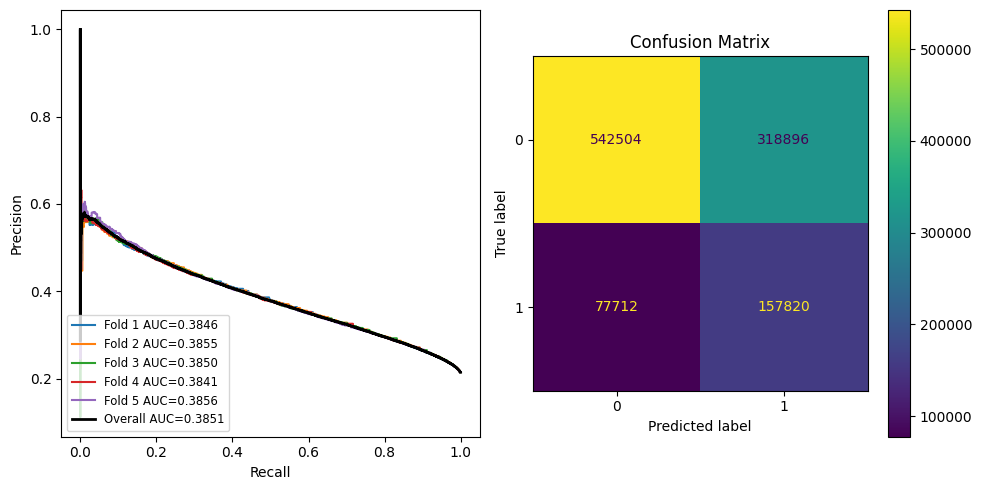

In [79]:
from sklearn.tree import DecisionTreeClassifier

from sklearn._config import set_config

set_config(transform_output="pandas")

params = {
    "class_weight": 'balanced',
    "max_depth": 10, 
    "random_state": 42
}

dt = DecisionTreeClassifier(**params)

model = ('Decision Tree Classifier', dt, params)

train(model, EXPERIMENT_NAME)

In [ ]:
# numerical_preprocessor = ColumnTransformer(
#     steps=[
#         ("imputation", SimpleImputer(strategy='median'), NUMERICAL_FEATURES), 
#         ("scaling", RobustScaler(), NUMERICAL_FEATURES)
#     ],
#     remainder='passthrough', 
#     verbose=True,
#     verbose_feature_names_out=False,
#     n_jobs=-1
# )

# categorical_preprocessor = ColumnTransformer(  
#     [
#         ("imputation", SimpleImputer(strategy='most_frequent'), CATEGORICAL_FEATURES), 
#         ("one_hot_encoding", OneHotEncoder(drop='first', dtype=np.int64), ['term']), 
#         ("ordinal_encoding", OrdinalEncoder(dtype=np.int64), ['sub_grade'])
#     ],
#     remainder='passthrough',
#     verbose=True, 
#     verbose_feature_names_out=False,
#     n_jobs=-1
# )

# lmao you wrote it wrong (study this again)

## 3. Model Selection 
Models to consider: 
- Logistic Regression 
- Random Forest 
- XGBoost 
- LightGBM
- Algorithms involving undersampling and oversampling methods to address class imbalance

Note: These models are cost-sensitive which means they have to be weighted using the class distribution to address the heavy class imbalance (except for those involving the sampling methods)


Create a new experiment 

In [ ]:
EXPERIMENT_NAME = "model_selection_experiment"
mlflow.set_experiment(EXPERIMENT_NAME)

### Logistic Regression

### Random Forest 

### XGBoost 

### LightGBM

### Sampling Methods

In [ ]:
# smote comes after scaling 